# Cinemática do Braço Esférico (Spherical Arm - RRP)
Este notebook utiliza a biblioteca `DH` refatorada para calcular a cinemática direta, a propagação de erros, os ângulos de Euler e plotar o mecanismo e o seu espaço de trabalho (Workspace) para um robô com juntas Rotativa-Rotativa-Prismática.

In [1]:
import sys
sys.path.append('../') 
%load_ext autoreload
%autoreload 2

import sympy as sp
import numpy as np
import DH

## 1. Construindo o Mecanismo e Variáveis

In [2]:
# Define the DH parameters: (Spherical Arm)
Spherical_Arm = [
    {'type': 'revolute', 'a': 0, 'alpha': -sp.pi/2, 'd': 0.0,
     'errors': {'sigma': 1.02469, 'epsilon': 0.3606, 'beta': 0.0181, 'phi': 0}},
    
    {'type': 'revolute', 'a': 0, 'alpha': sp.pi/2,  'd': 10,
     'errors': {'sigma': 1.02469, 'epsilon': 0.3606, 'beta': 0.0181, 'phi': 0}},

    {'type': 'prismatic', 'a': 0, 'alpha': 0, 'theta_offset': 0,
     'errors': {'sigma': 1.02469, 'epsilon': 0.3606, 'beta': 0.0181, 'phi': 0}}
]

# Create the robot and the plotter:
robot = DH.Mechanism(Spherical_Arm)
plotter = DH.MechanismPlotter(robot)

# Evaluate the position of the effector using optional variable values:
variable_values = {
    robot.theta[0]: sp.pi/12,   # theta_0 for the first joint
    robot.theta[1]: sp.pi/6,    # theta_1 for the second joint
    robot.d[2]: 10,             # d_2 for the prismatic joint (Extensão em mm)
}

# Ranges de movimento para o Workspace (Monte Carlo)
ranges_movimento = {
    robot.theta[0]: (-sp.pi, sp.pi),       # Rotação da base: 360 graus
    robot.theta[1]: (-sp.pi/4, sp.pi/2),   # Elevação do ombro
    robot.d[2]: (5, 50)                    # Extensão da junta prismática (5mm a 50mm)
}

## 2. Cálculos Algébricos Simbólicos

In [3]:
"""Begin the calculations algebrically"""

# Calculate the forward kinematics without errors:
matrix_g, position_g = robot.forward_kinematics(apply_errors=False)
print("Matrix and position algebrical without errors:\n")
print("Matrix:\n", matrix_g)
print("\nPosition:\n", position_g)

# Calculate the forward kinematics with errors:
matrix_g_e, position_g_e = robot.forward_kinematics(apply_errors=True)
print("\nMatrix and position algebrical with errors:\n")
print("Matrix:\n", matrix_g_e)
print("\nPosition:\n", position_g_e)

Matrix and position algebrical without errors:

Matrix:
 Matrix([[-(sin(theta_0)*sin(theta_1)*cos(alpha_0) - cos(theta_0)*cos(theta_1))*cos(theta_2) - (-sin(alpha_0)*sin(alpha_1)*sin(theta_0) + sin(theta_0)*cos(alpha_0)*cos(alpha_1)*cos(theta_1) + sin(theta_1)*cos(alpha_1)*cos(theta_0))*sin(theta_2), (sin(theta_0)*sin(theta_1)*cos(alpha_0) - cos(theta_0)*cos(theta_1))*sin(theta_2)*cos(alpha_2) - (-sin(alpha_0)*sin(alpha_1)*sin(theta_0) + sin(theta_0)*cos(alpha_0)*cos(alpha_1)*cos(theta_1) + sin(theta_1)*cos(alpha_1)*cos(theta_0))*cos(alpha_2)*cos(theta_2) + (sin(alpha_0)*sin(theta_0)*cos(alpha_1) + sin(alpha_1)*sin(theta_0)*cos(alpha_0)*cos(theta_1) + sin(alpha_1)*sin(theta_1)*cos(theta_0))*sin(alpha_2), -(sin(theta_0)*sin(theta_1)*cos(alpha_0) - cos(theta_0)*cos(theta_1))*sin(alpha_2)*sin(theta_2) + (-sin(alpha_0)*sin(alpha_1)*sin(theta_0) + sin(theta_0)*cos(alpha_0)*cos(alpha_1)*cos(theta_1) + sin(theta_1)*cos(alpha_1)*cos(theta_0))*sin(alpha_2)*cos(theta_2) + (sin(alpha_0)*sin(theta

## 3. Matrizes Nominais (Validação de Livro)

In [4]:
"""Begin the calculations numerically (Book Validation):"""

# Sem enviar as variable_values, os símbolos móveis são mantidos
matrix_g_num, position_g_num, orientation_g_num = robot.evaluate_param(T=matrix_g, apply_errors=False)
print("\nMatrix and position numerical without errors (Book Validation):\n")
print("Matrix:\n", matrix_g_num)
print("\nPosition:\n", position_g_num)

matrix_ge_num, position_ge_num, orientation_ge_num = robot.evaluate_param(T=matrix_g_e, apply_errors=True)
print("\nMatrix and position numerical with errors (Book Validation):\n")
print("Matrix:\n", matrix_ge_num)
print("\nPosition:\n", position_ge_num)


Matrix and position numerical without errors (Book Validation):

Matrix:
 Matrix([[1, 0, 0, 0], [0, 1, 0, 10], [0, 0, 1, 0], [0, 0, 0, 1]])

Position:
 Matrix([[0], [10], [0]])

Matrix and position numerical with errors (Book Validation):

Matrix:
 Matrix([[1, 0, 0, 3.07407000000000], [0, 0.998526117197454, -0.0542733200990748, 10.3458520590819], [0, 0.0542733200990748, 0.998526117197454, 0.908480374357222], [0, 0, 0, 1]])

Position:
 Matrix([[3.07407000000000], [10.3458520590819], [0.908480374357222]])


## 4. Aplicação das Variáveis e Propagação de Erros (Resultados de Pesquisa)

In [5]:
"""Results for research purposes (Applying values):"""

matrix_num, position_num, orientation_num = robot.evaluate_param(T=matrix_g, variable_values=variable_values, apply_errors=False)
matrix_num_e, position_num_e, orientation_num_e = robot.evaluate_param(T=matrix_g_e, variable_values=variable_values, apply_errors=True)

# Calculate error values:
print("[X, Y, Z] position values:")
print("Position without errors: \n", np.round(position_num, 4))
print("Position with errors: \n", np.round(position_num_e, 4))

error = DH.Mechanism.evaluate_error(position_num, position_num_e)
print("\nError value in mm: \n", round(error, 4))

# Calculate the euler angles:
print("\nEuler angles: Yaw(Z), Pitch(Y), Roll(X) in radians")
print("Without errors: \n", np.round(DH.Mechanism.get_euler_angles(orientation_num), 4))
print("With errors: \n", np.round(DH.Mechanism.get_euler_angles(orientation_num_e), 4))

[X, Y, Z] position values:
Position without errors: 
 [ 2.2414 10.9534  8.6603]
Position with errors: 
 [ 5.1117 11.751   8.4898]

Error value in mm: 
 2.984

Euler angles: Yaw(Z), Pitch(Y), Roll(X) in radians
Without errors: 
 [0.     0.5236 0.2618]
With errors: 
 [0.0571 0.5235 0.2722]


## 5. Visualização Cinemática e Espaço de Trabalho (Workspace)

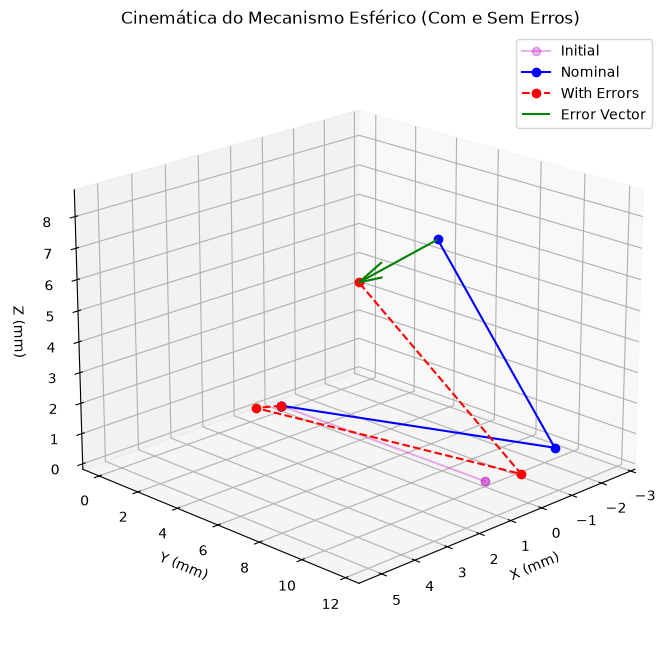

In [6]:
# Plot the robot:
plotter.plot_mechanism(
    variable_values=variable_values, 
    title='Cinemática do Mecanismo Esférico (Com e Sem Erros)', 
    plot_type='3d'
)

In [8]:
# 1. Definir a posição inicial (origem e junta prismática recolhida)
posicao_inicial = {
    robot.theta[0]: 0.0,
    robot.theta[1]: 0.0,
    robot.d[2]: 0.0
}

# 2. Definir a posição final (convertendo pi para float)
posicao_final = {
    robot.theta[0]: float(sp.pi/12), # Rotação
    robot.theta[1]: float(sp.pi/6),  # Elevação
    robot.d[2]: 10.0                 # Extensão prismática (10 mm)
}

# 3. Gerar a simulação em 3D
plotter.simulate_movement(
    start_values=posicao_inicial, 
    end_values=posicao_final, 
    frames=60,
    interval=40,
    plot_type='3d',
    title="Simulação de Movimento - Braço Esférico (RRP)"
)

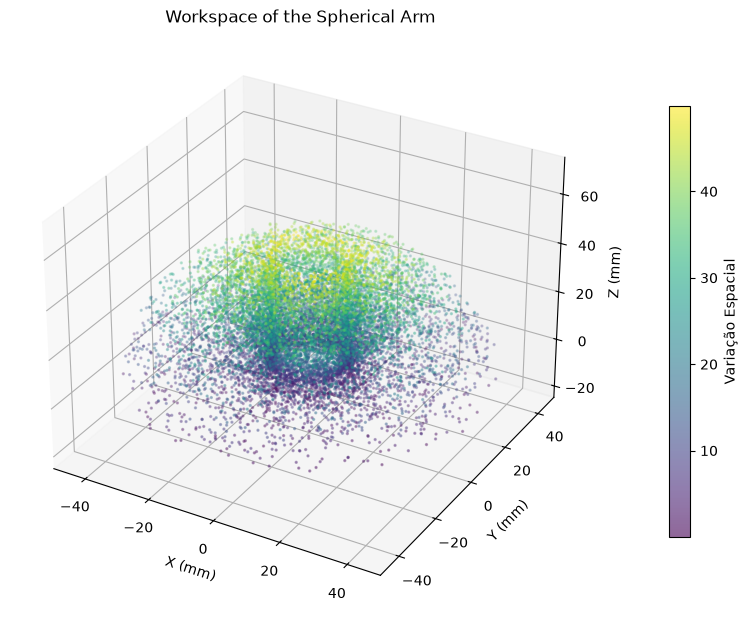

In [7]:
# Plotting the workspace (Monte Carlo Sampling)
plotter.plot_workspace(
    joint_ranges=ranges_movimento,
    num_samples=15000,
    apply_errors=False,
    title='Workspace of the Spherical Arm'
)